Loading datasets...

1. PRODUCT APPEARANCE FREQUENCIES IN ORDER BOOK
VEV_4000                 : 30000/330000 (09.09%)
VEV_4500                 : 30000/330000 (09.09%)
VEV_5000                 : 30000/330000 (09.09%)
VEV_5100                 : 30000/330000 (09.09%)
VEV_5200                 : 30000/330000 (09.09%)
VEV_5300                 : 30000/330000 (09.09%)
VEV_5400                 : 30000/330000 (09.09%)
VEV_5500                 : 30000/330000 (09.09%)
VEV_6000                 : 30000/330000 (09.09%)
VEV_6500                 : 30000/330000 (09.09%)
VELVETFRUIT_EXTRACT      : 30000/330000 (09.09%)

2. LOB PRICES AND VOLUMES (L1-L3) - DESCRIPTIVE STATS
Mean values for LOB (Quick View):
                     bid_price_1  bid_price_2  bid_price_3  bid_volume_1  \
product                                                                    
VEV_4000                 1239.70      1237.14      1237.38         10.92   
VEV_4500                  742.18       740.26       740.51          8.95   

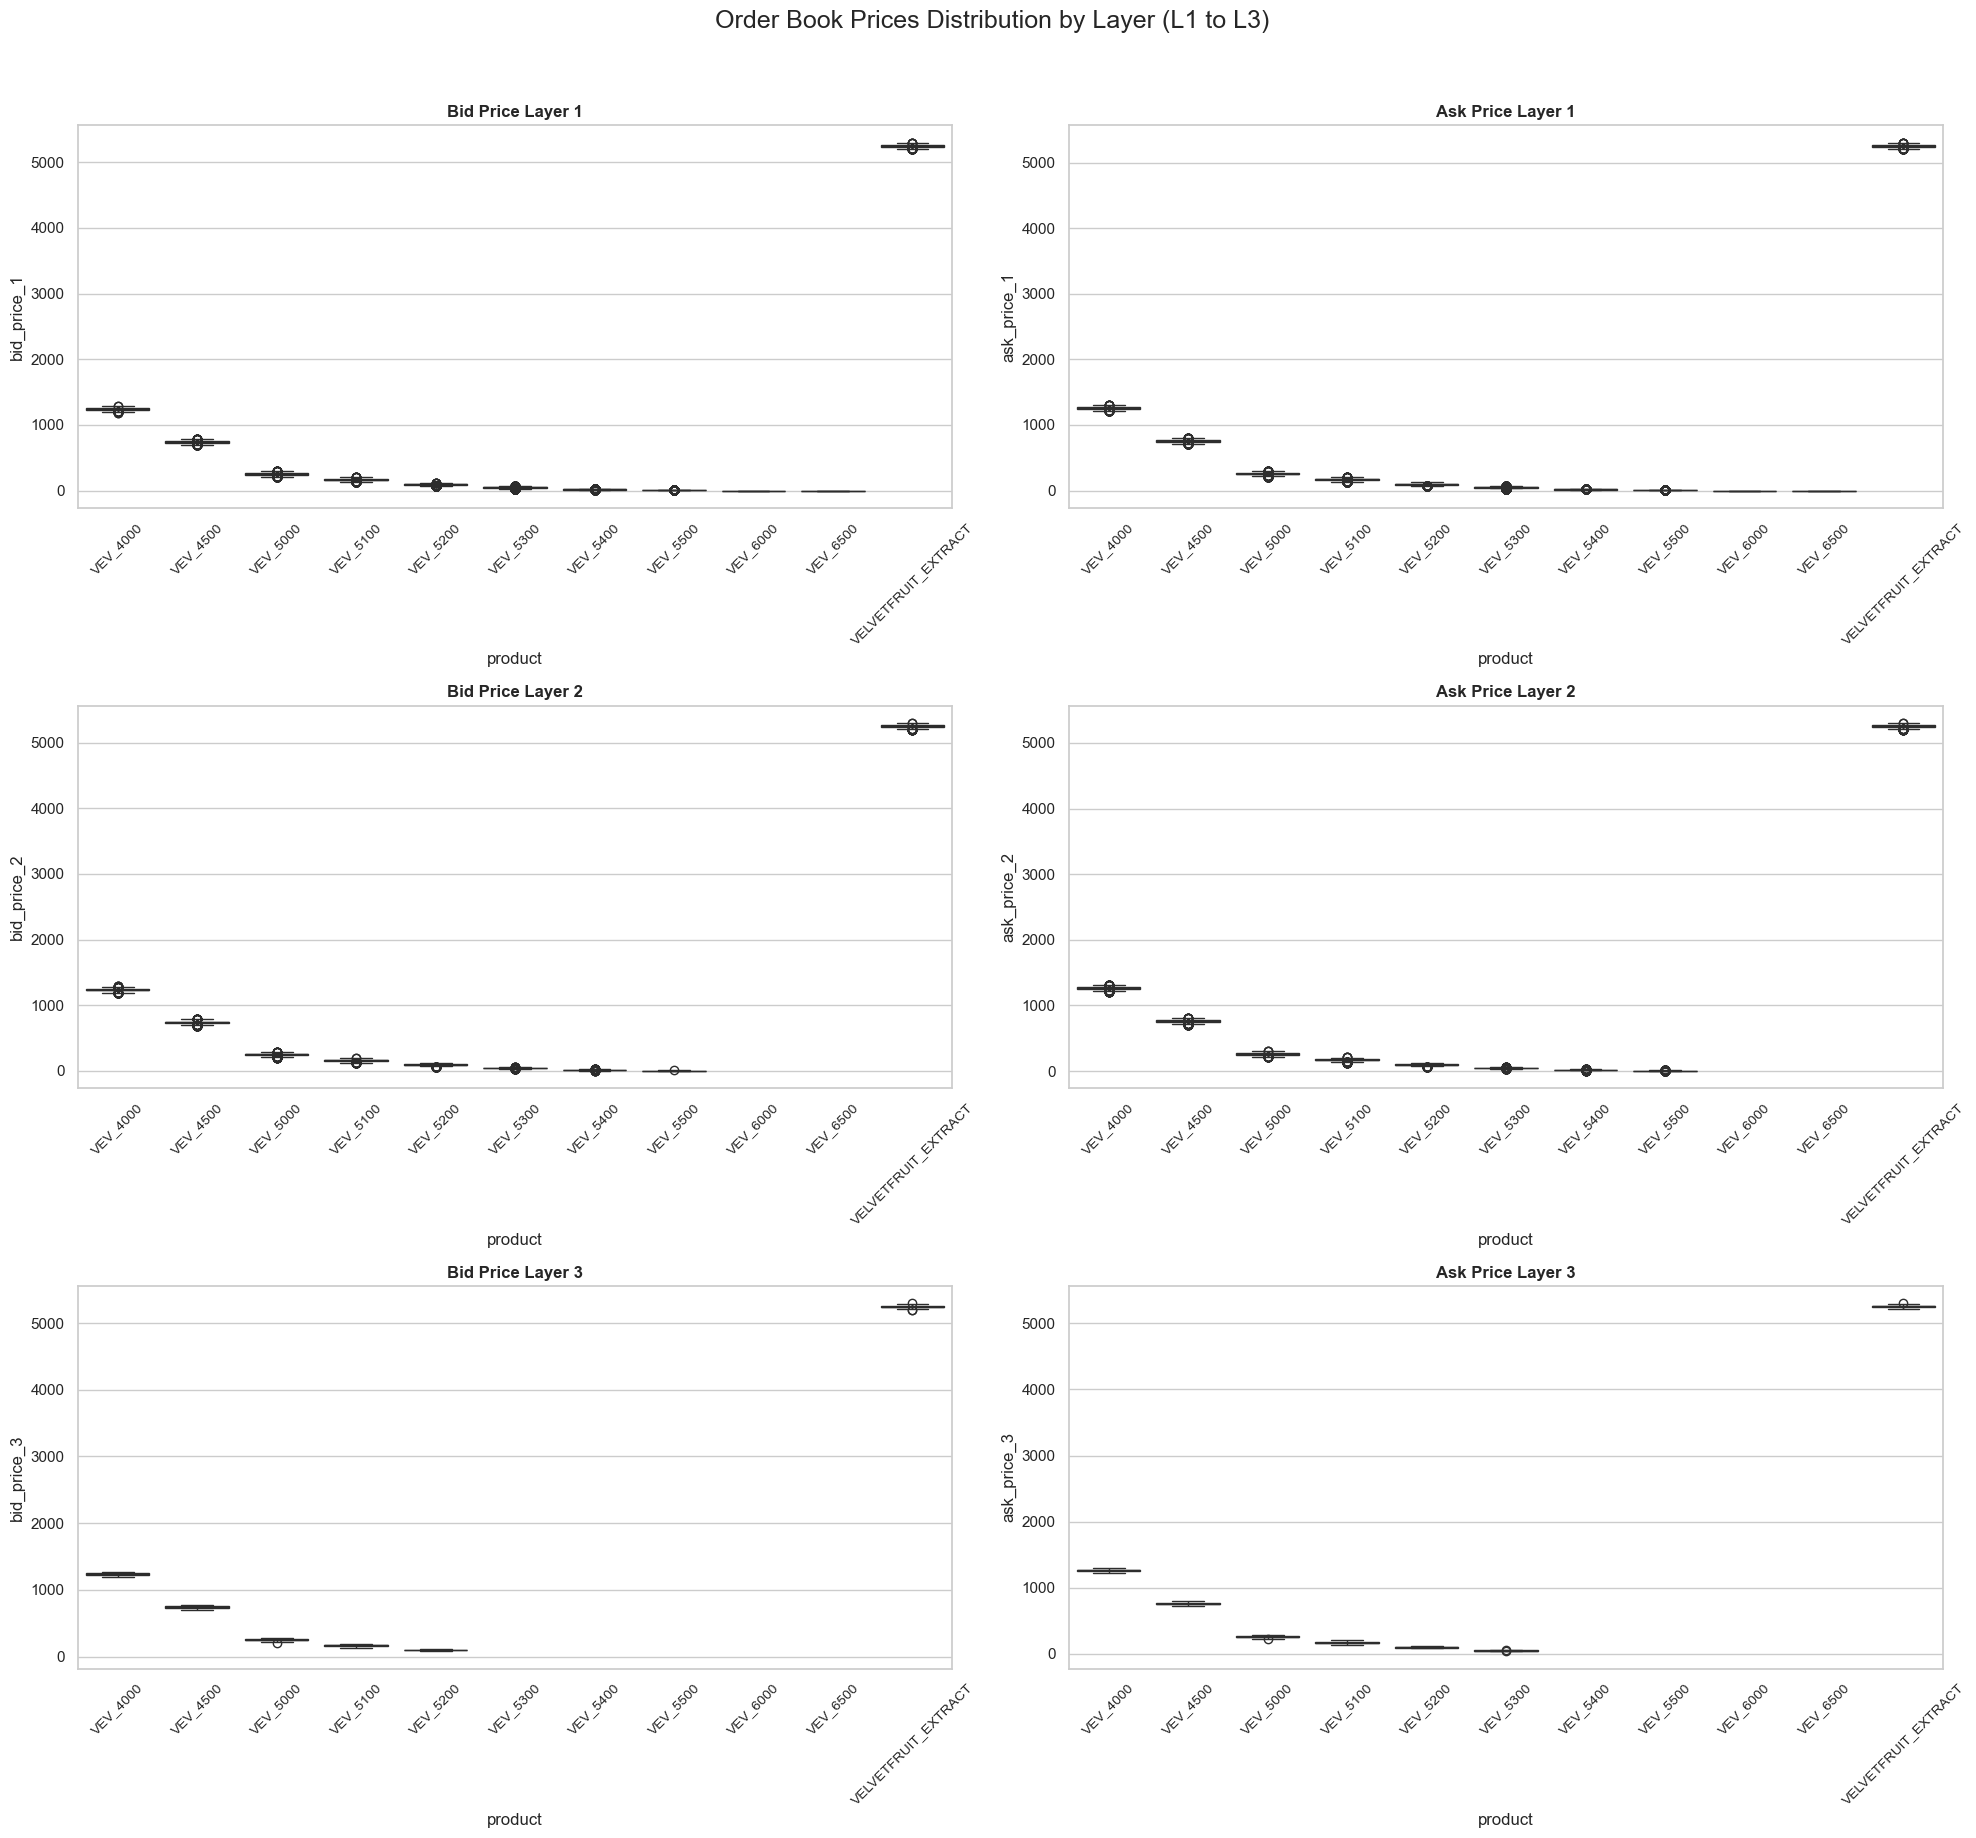

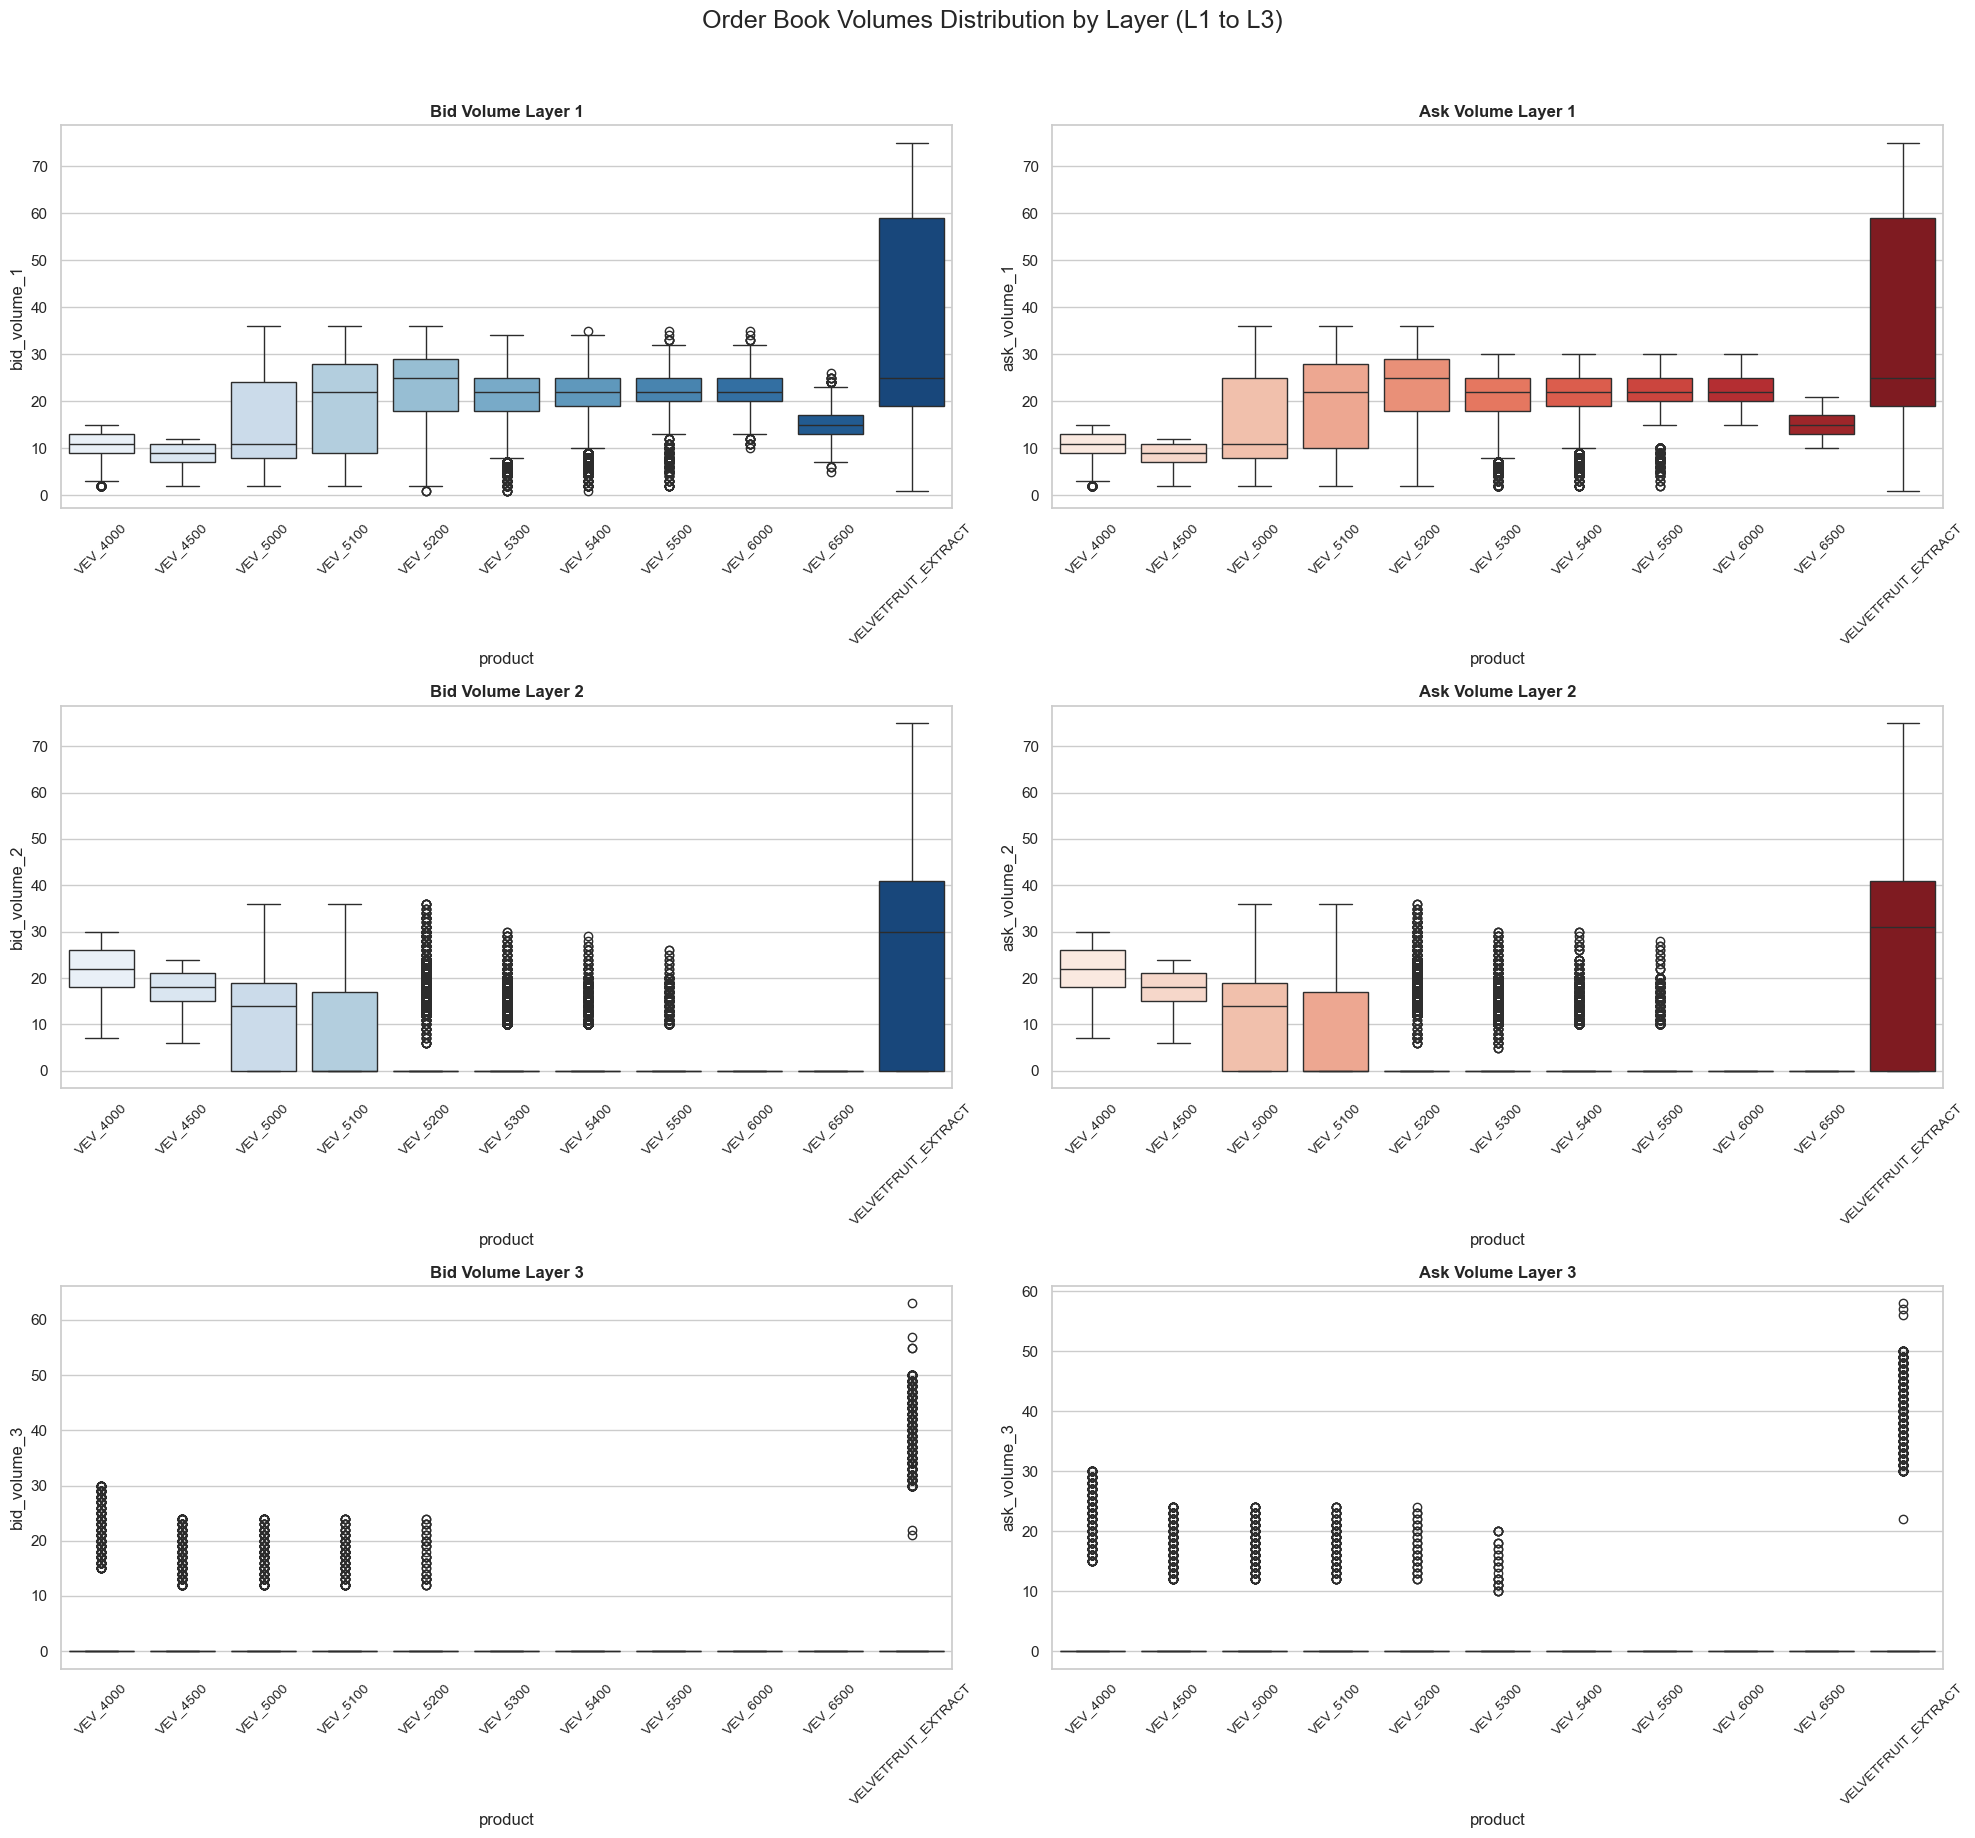


3. ADVANCED ORDER BOOK METRICS - DESCRIPTIVE STATS
Mean values for Advanced Metrics:
                     mid_price     depth    dom_mid  deep_vamp     obi  \
product                                                                  
VEV_4000             1250.1098   67.0334  1250.1083  1250.1163 -0.0000   
VEV_4500              750.1096   54.0252   750.1081   750.1167 -0.0000   
VEV_5000              255.0224   54.0252   255.0080   255.0243 -0.0000   
VEV_5100              166.8054   54.0252   166.7965   166.8079 -0.0000   
VEV_5200               95.5488   54.0211    95.5482    95.5536 -0.0001   
VEV_5300               46.7599   44.9939    46.7600    46.7616 -0.0001   
VEV_5400               15.9519   44.9694    15.9525    15.9529 -0.0002   
VEV_5500                6.6414   44.9594     6.6414     6.6416 -0.0002   
VEV_6000                0.5000   44.9550     0.4999     0.5001 -0.0002   
VEV_6500                0.5000   30.9616     0.4998     0.5002 -0.0004   
VELVETFRUIT_EXTRACT  5250.

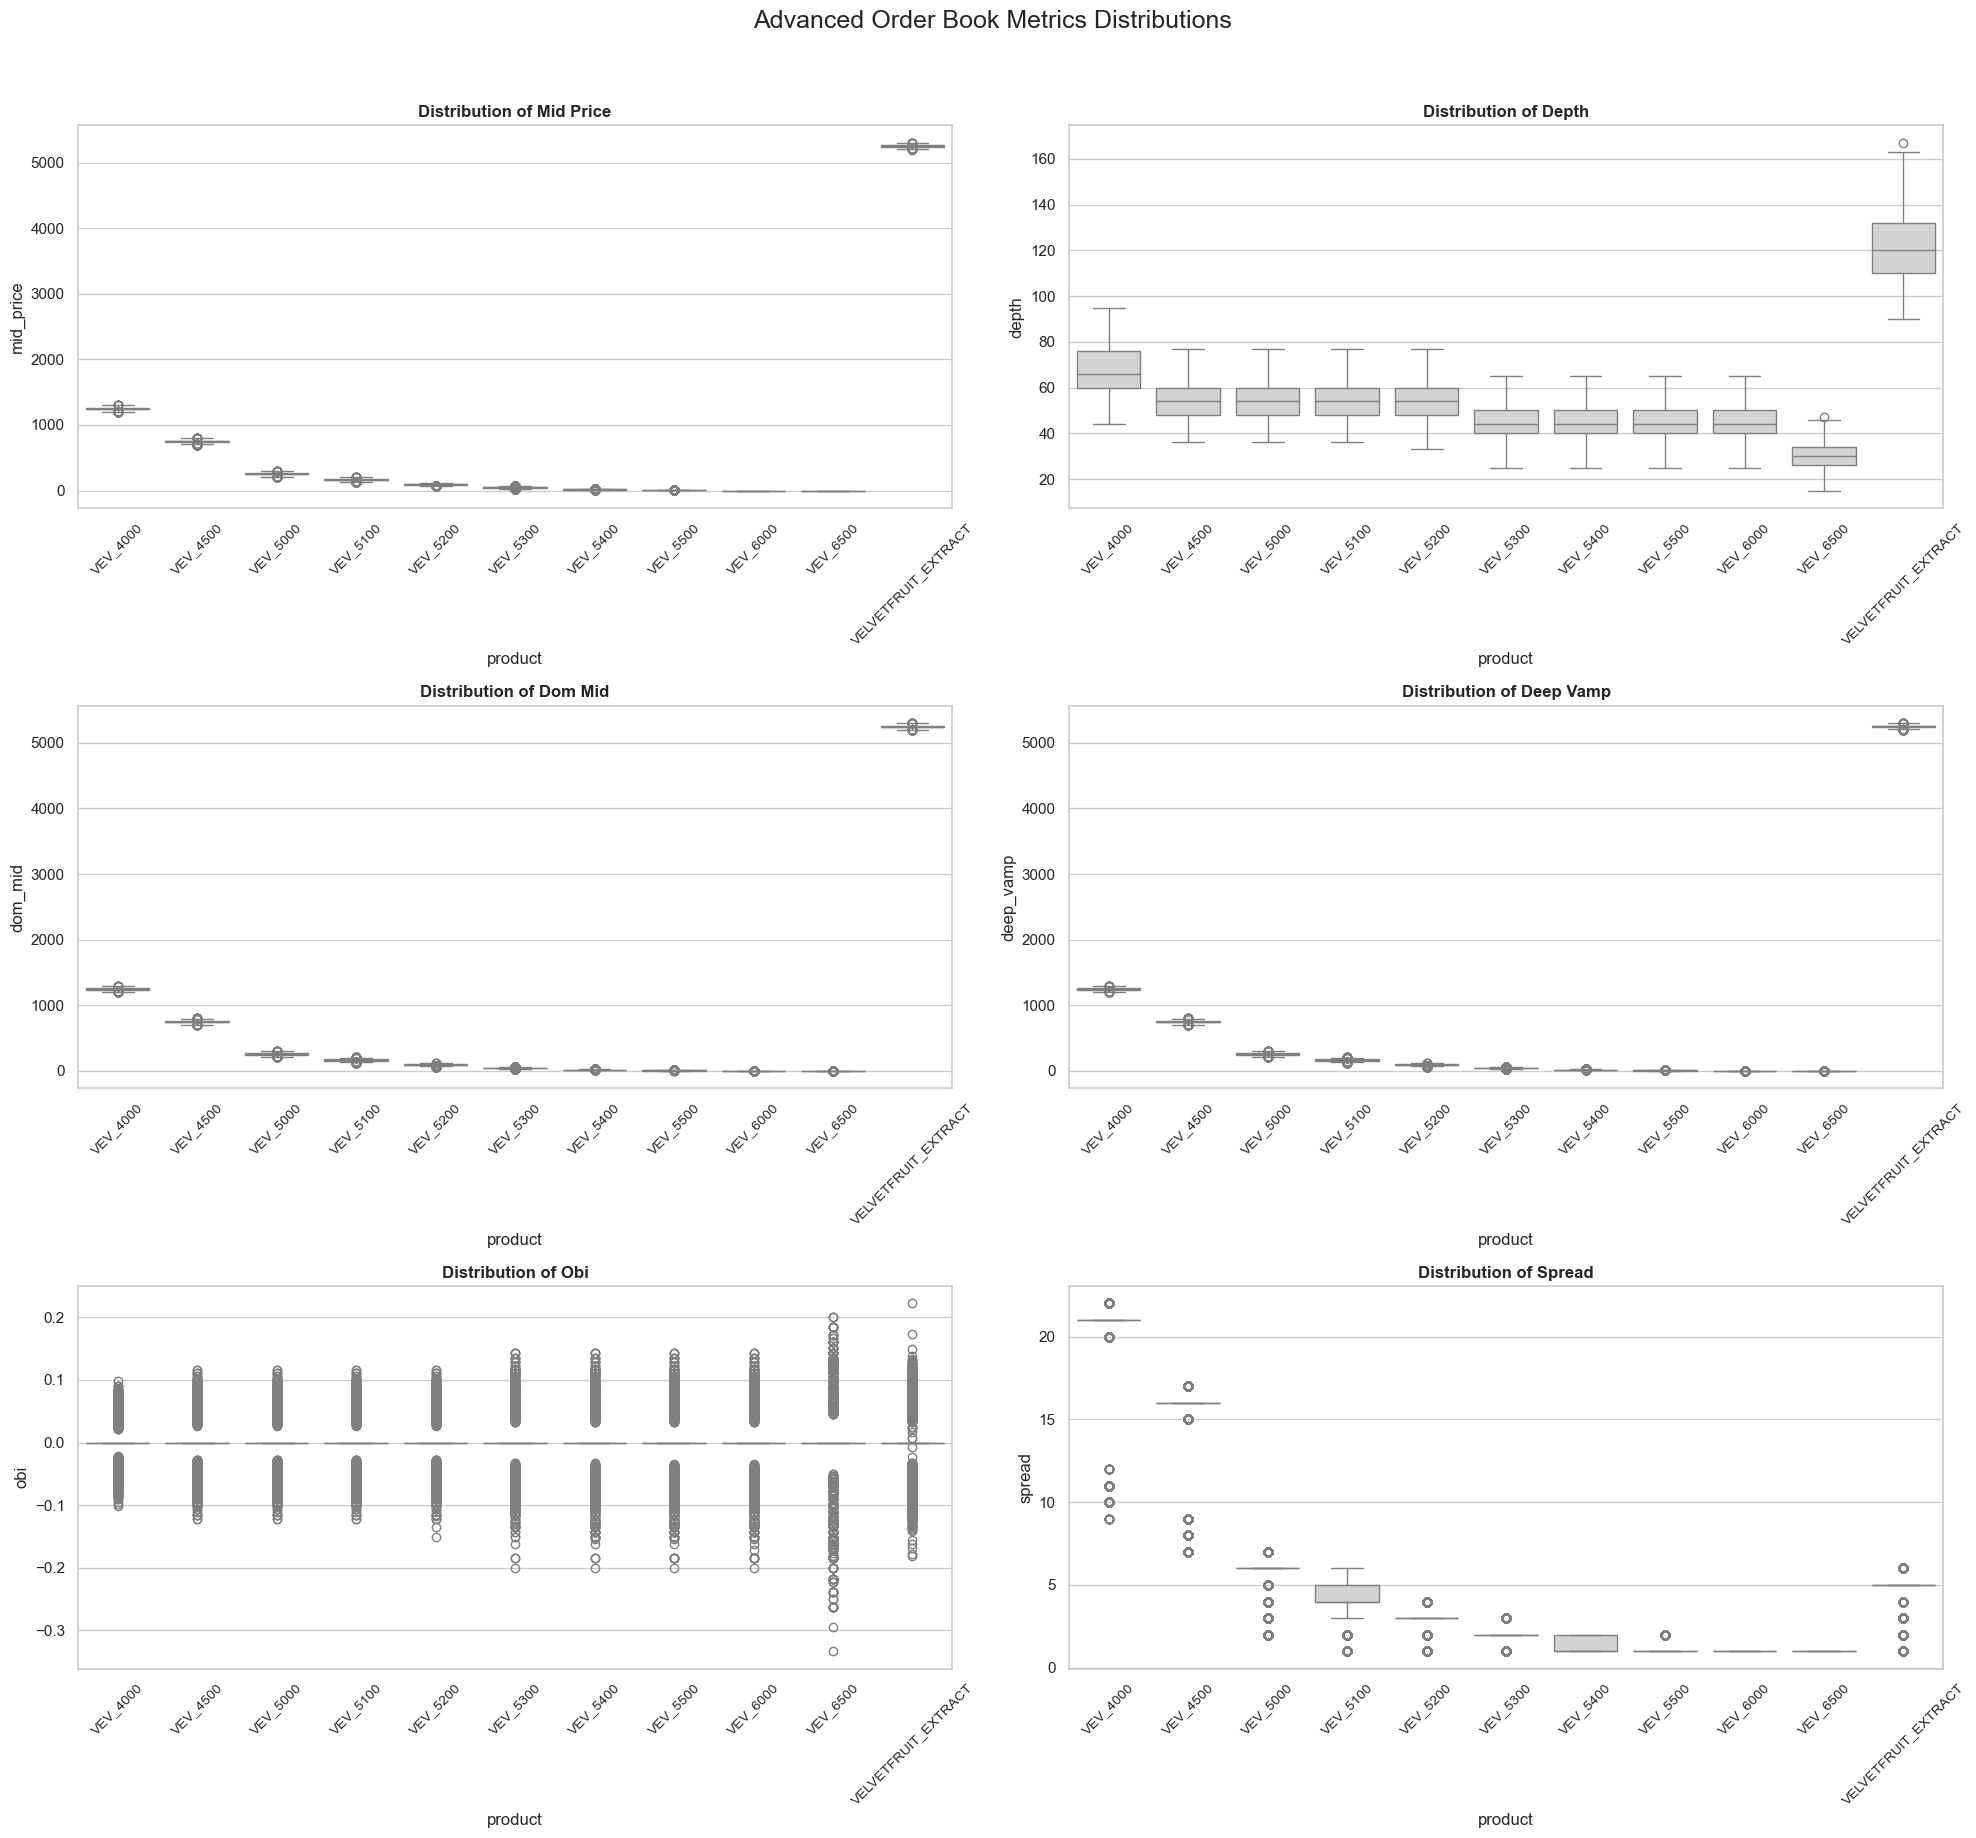


4. ORDER BOOK TICK DISTANCES (GAPS BETWEEN APPEARANCES)
Average Ticks Between LOB Appearances (1 Tick = 100 timestamp):
product
VEV_4000               1.0
VEV_4500               1.0
VEV_5000               1.0
VEV_5100               1.0
VEV_5200               1.0
VEV_5300               1.0
VEV_5400               1.0
VEV_5500               1.0
VEV_6000               1.0
VEV_6500               1.0
VELVETFRUIT_EXTRACT    1.0
Name: tick_diff, dtype: float64


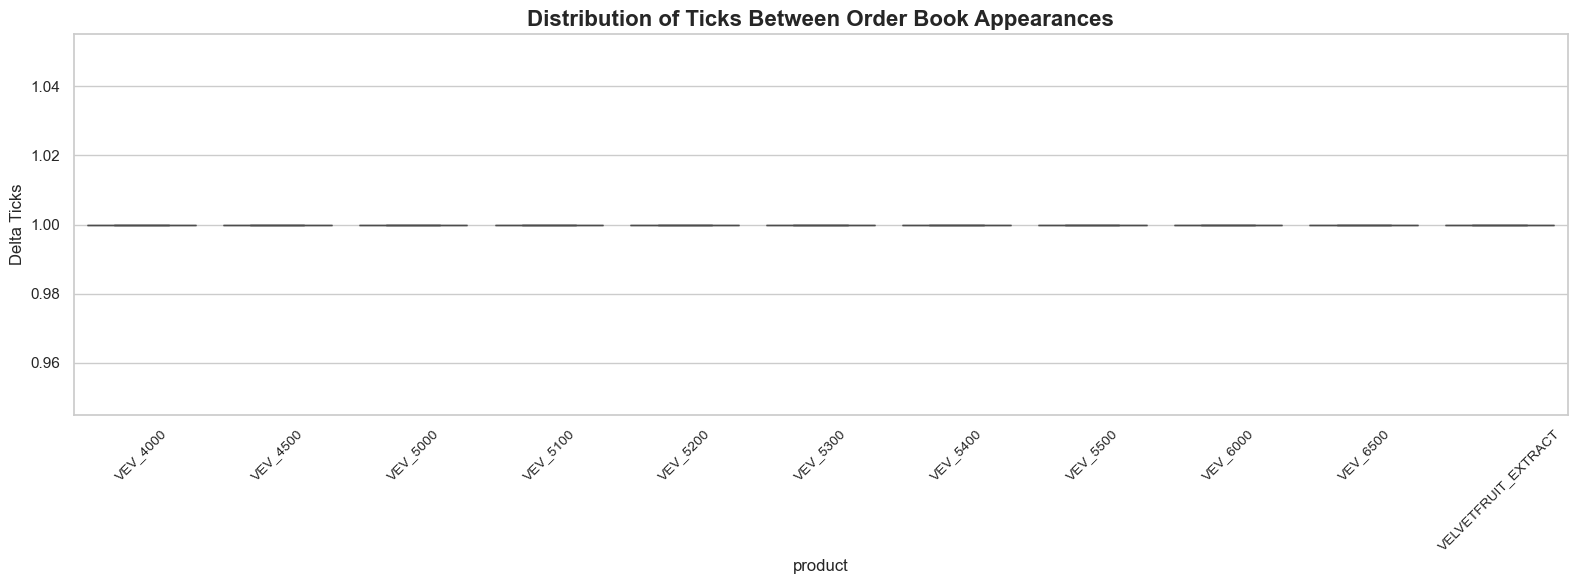


5. TRADES ANALYSIS - DESCRIPTIVE STATS
Trades Count per Product per Day:
product  VEV_4000  VEV_4500  VEV_5000  VEV_5100  VEV_5200  VEV_5300  VEV_5400  \
day                                                                             
0             172         0         0         0         3        37        64   
1             164         1         1         1         7        39        81   
2             128         0         0         0         8        45        80   

product  VEV_5500  VEV_6000  VEV_6500  VELVETFRUIT_EXTRACT  
day                                                         
0              81        91        91                  445  
1              92        98        98                  450  
2              94        95        95                  477  

Mean Trade Metrics:
                       price  quantity  trade_tick_diff
product                                                
VEV_4000             1249.81      2.03            64.66
VEV_4500              733.

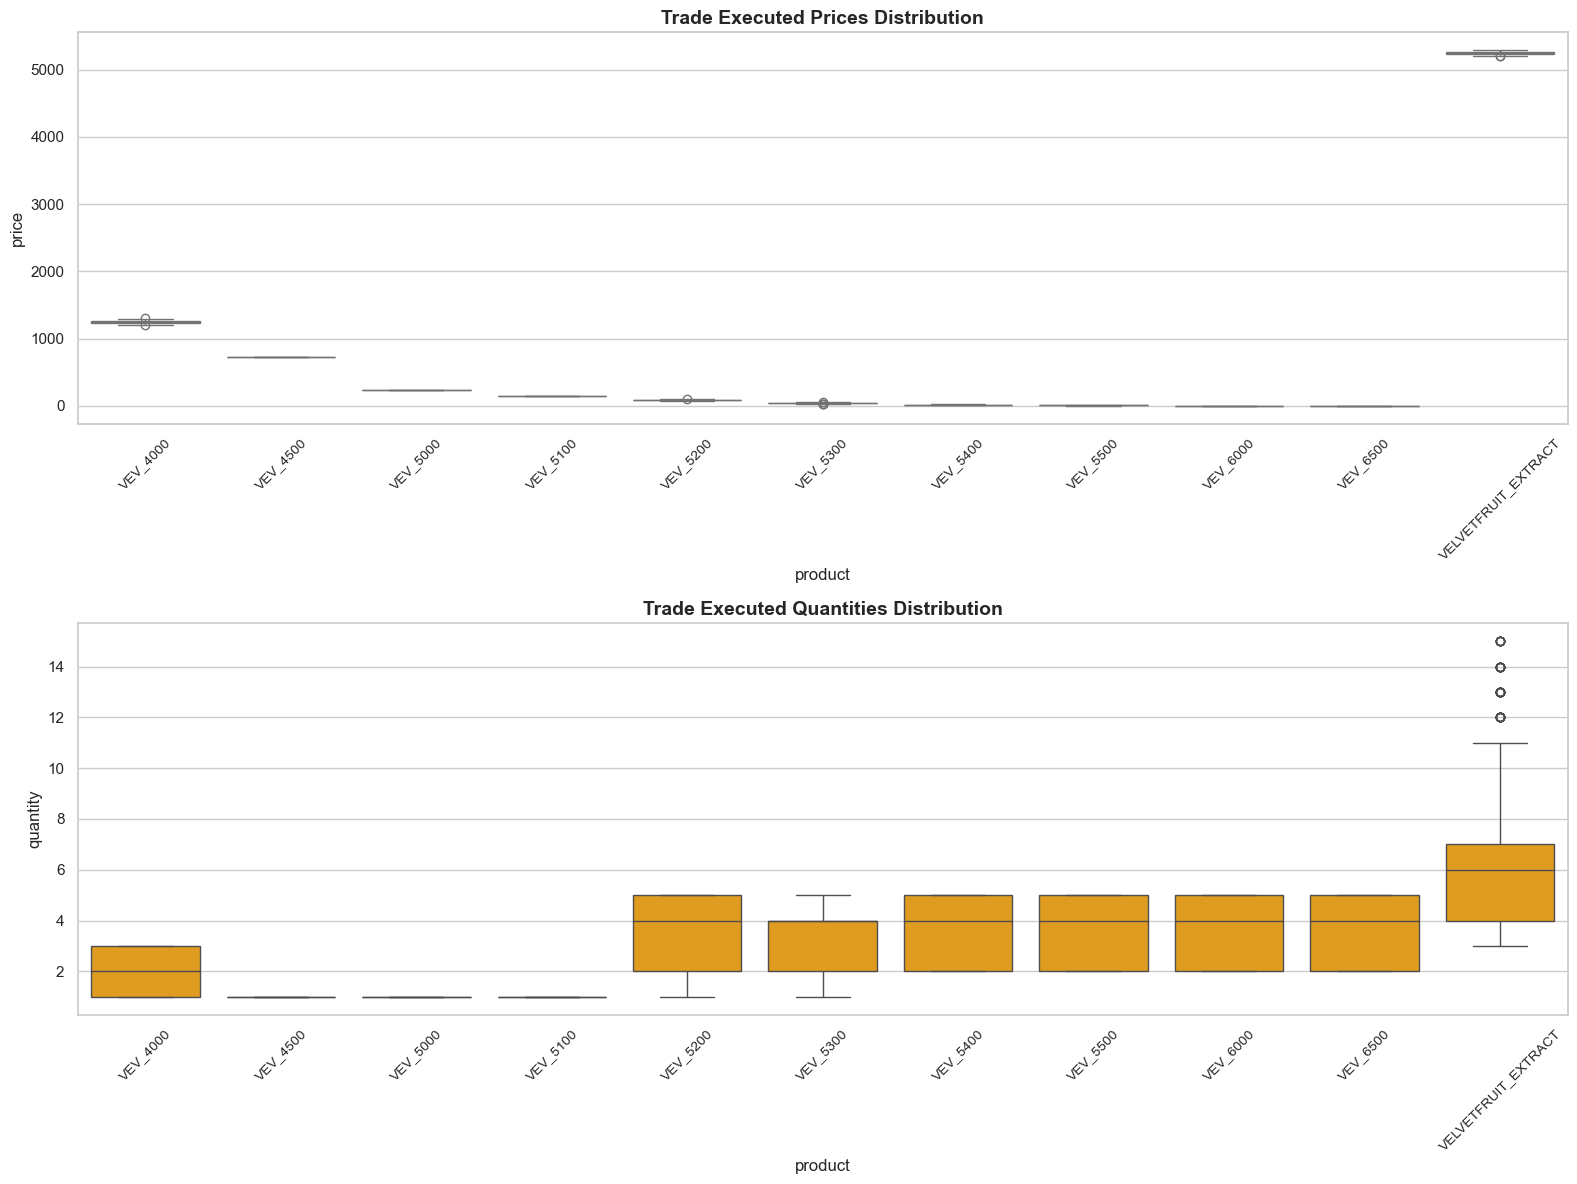


6. LOB DEPLETION (LIQUIDITY CONSUMPTION & COORDINATES)

--- Instances consuming AT LEAST Layer 1 ---
                     instances  avg_price  avg_qty
product                                           
VEV_5200                   7.0      85.86     4.86
VEV_5300                  19.0      46.42     4.42
VEV_5400                   5.0      17.40     4.20
VEV_5500                   5.0       6.40     4.60
VEV_6500                   1.0       0.00     5.00
VELVETFRUIT_EXTRACT      188.0    5251.43     9.07

--- Instances consuming AT LEAST Layer 2 ---
Total instances found: 1
 day  timestamp  product  total_trade_qty  avg_trade_price
   0     640300 VEV_6500                5              0.0

--- Instances consuming AT LEAST Layer 3 ---
Total instances found: 1
 day  timestamp  product  total_trade_qty  avg_trade_price
   0     640300 VEV_6500                5              0.0

7. LOB ANOMALOUS STATES (EMPTY OR ONE-SIDED LAYERS)
Counts of anomalous order book states per product:
        

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configuration
def resolve_data_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / 'imc-prosperity-4',
        Path.cwd().parent / 'imc-prosperity-4',
    ]
    for base in candidates:
        data_dir = base / 'phase2' / 'round3' / 'data'
        if data_dir.exists():
            return data_dir
    raise FileNotFoundError('Could not locate phase2/round3/data from current working directory')

DATA_DIR = resolve_data_dir()
PRICES_FILE = DATA_DIR / 'prices_round_3_combined.csv'
TRADES_FILE = DATA_DIR / 'trades_round_3_combined.csv'

# Strict Ordering constraint
SORTED_PRODUCTS = [
    'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 
    'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500', 
    'VELVETFRUIT_EXTRACT'
]

# Set Seaborn aesthetic style for dense grid plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['xtick.labelsize'] = 10

def load_and_preprocess():
    print("Loading datasets...")
    if not PRICES_FILE.exists() or not TRADES_FILE.exists():
        raise FileNotFoundError(
            f"Missing dataset files. Expected: {PRICES_FILE} and {TRADES_FILE}"
        )

    df_prices = pd.read_csv(PRICES_FILE, sep=';')
    df_trades = pd.read_csv(TRADES_FILE, sep=';')
    
    # Filter targets
    df_prices = df_prices[df_prices['product'].isin(SORTED_PRODUCTS)].copy()
    
    if 'symbol' in df_trades.columns:
        df_trades.rename(columns={'symbol': 'product'}, inplace=True)
    df_trades = df_trades[df_trades['product'].isin(SORTED_PRODUCTS)].copy()
    
    # Prosperity engine registers ask volumes as negative. Force absolute values.
    # fillna(0) ensures numerical calculations handle empty layers properly.
    for col in df_prices.columns:
        if 'volume' in col:
            df_prices[col] = df_prices[col].abs().fillna(0)
            
    df_trades['quantity'] = df_trades['quantity'].abs()
    
    # Convert product to categorical for strict sorting in dataframes
    df_prices['product'] = pd.Categorical(df_prices['product'], categories=SORTED_PRODUCTS, ordered=True)
    df_trades['product'] = pd.Categorical(df_trades['product'], categories=SORTED_PRODUCTS, ordered=True)
    
    return df_prices, df_trades

def run_eda(df_prices, df_trades):
    # ---------------------------------------------------------
    # 1. Product Appearance Frequencies
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("1. PRODUCT APPEARANCE FREQUENCIES IN ORDER BOOK")
    print("="*50)
    total_quotes = len(df_prices)
    counts = df_prices['product'].value_counts()
    
    for prod in SORTED_PRODUCTS:
        c = counts.get(prod, 0)
        frac = c / total_quotes if total_quotes > 0 else 0
        print(f"{prod:<25}: {c}/{total_quotes} ({frac*100:05.2f}%)")

    # ---------------------------------------------------------
    # 2. Average LOB Prices and Volumes
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("2. LOB PRICES AND VOLUMES (L1-L3) - DESCRIPTIVE STATS")
    print("="*50)
    lob_cols = [f'{side}_{metric}_{level}' for side in ['bid', 'ask'] 
                for metric in ['price', 'volume'] for level in [1, 2, 3]]
    
    print("Mean values for LOB (Quick View):")
    stats_lob_mean = df_prices.groupby('product', observed=True)[lob_cols].mean().reindex(SORTED_PRODUCTS).round(2)
    print(stats_lob_mean)
    
    print("\nDescriptive Statistics (Min, Max, Median, Std, etc.) for LOB Variables:")
    # We display descriptive stats for L1 specifically to avoid console overflow, 
    # but the logic applies to all requested variables.
    l1_cols = ['bid_price_1', 'ask_price_1', 'bid_volume_1', 'ask_volume_1']
    stats_lob_desc = df_prices.groupby('product', observed=True)[l1_cols].describe().reindex(SORTED_PRODUCTS).round(2)
    print(stats_lob_desc)
    
    # PLOT: LOB Prices
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle('Order Book Prices Distribution by Layer (L1 to L3)', fontsize=18, y=1.02)
    
    for i, level in enumerate([1, 2, 3]):
        sns.boxplot(data=df_prices, x='product', y=f'bid_price_{level}', ax=axes[i, 0], palette="Blues", order=SORTED_PRODUCTS)
        axes[i, 0].set_title(f'Bid Price Layer {level}', fontweight='bold')
        axes[i, 0].tick_params(axis='x', rotation=45)
        
        sns.boxplot(data=df_prices, x='product', y=f'ask_price_{level}', ax=axes[i, 1], palette="Reds", order=SORTED_PRODUCTS)
        axes[i, 1].set_title(f'Ask Price Layer {level}', fontweight='bold')
        axes[i, 1].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()

    # PLOT: LOB Volumes
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle('Order Book Volumes Distribution by Layer (L1 to L3)', fontsize=18, y=1.02)
    
    for i, level in enumerate([1, 2, 3]):
        sns.boxplot(data=df_prices, x='product', y=f'bid_volume_{level}', ax=axes[i, 0], palette="Blues", order=SORTED_PRODUCTS)
        axes[i, 0].set_title(f'Bid Volume Layer {level}', fontweight='bold')
        axes[i, 0].tick_params(axis='x', rotation=45)
        
        sns.boxplot(data=df_prices, x='product', y=f'ask_volume_{level}', ax=axes[i, 1], palette="Reds", order=SORTED_PRODUCTS)
        axes[i, 1].set_title(f'Ask Volume Layer {level}', fontweight='bold')
        axes[i, 1].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. Advanced Order Book Metrics
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("3. ADVANCED ORDER BOOK METRICS - DESCRIPTIVE STATS")
    print("="*50)
    
    df_prices['depth'] = df_prices[['bid_volume_1', 'bid_volume_2', 'bid_volume_3', 
                                    'ask_volume_1', 'ask_volume_2', 'ask_volume_3']].sum(axis=1)
    
    vol_imbalance_denom = df_prices['bid_volume_1'] + df_prices['ask_volume_1']
    df_prices['dom_mid'] = np.where(vol_imbalance_denom > 0, 
                                    (df_prices['bid_price_1'] * df_prices['ask_volume_1'] + 
                                     df_prices['ask_price_1'] * df_prices['bid_volume_1']) / vol_imbalance_denom,
                                    df_prices['mid_price'])
    
    total_val = (df_prices['bid_price_1'].fillna(0) * df_prices['bid_volume_1'] +
                 df_prices['bid_price_2'].fillna(0) * df_prices['bid_volume_2'] +
                 df_prices['bid_price_3'].fillna(0) * df_prices['bid_volume_3'] +
                 df_prices['ask_price_1'].fillna(0) * df_prices['ask_volume_1'] +
                 df_prices['ask_price_2'].fillna(0) * df_prices['ask_volume_2'] +
                 df_prices['ask_price_3'].fillna(0) * df_prices['ask_volume_3'])
    
    df_prices['deep_vamp'] = np.where(df_prices['depth'] > 0, total_val / df_prices['depth'], np.nan)
    
    total_bid_vol = df_prices[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].sum(axis=1)
    total_ask_vol = df_prices[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].sum(axis=1)
    df_prices['obi'] = np.where(df_prices['depth'] > 0, (total_bid_vol - total_ask_vol) / df_prices['depth'], 0)
    df_prices['spread'] = df_prices['ask_price_1'] - df_prices['bid_price_1']
    
    metrics = ['mid_price', 'depth', 'dom_mid', 'deep_vamp', 'obi', 'spread']
    
    print("Mean values for Advanced Metrics:")
    stats_adv_mean = df_prices.groupby('product', observed=True)[metrics].mean().reindex(SORTED_PRODUCTS).round(4)
    print(stats_adv_mean)
    
    print("\nDescriptive Statistics (Min, Max, Median, Std, etc.) for Advanced Metrics:")
    stats_adv_desc = df_prices.groupby('product', observed=True)[metrics].describe().reindex(SORTED_PRODUCTS).round(4)
    print(stats_adv_desc)
    
    # PLOT: Advanced Metrics Grid
    fig, axes = plt.subplots(3, 2, figsize=(20, 18))
    fig.suptitle('Advanced Order Book Metrics Distributions', fontsize=18, y=1.02)
    
    for idx, metric in enumerate(metrics):
        r, c = divmod(idx, 2)
        sns.boxplot(data=df_prices, x='product', y=metric, ax=axes[r, c], color='lightgray', order=SORTED_PRODUCTS)
        axes[r, c].set_title(f'Distribution of {metric.replace("_", " ").title()}', fontweight='bold')
        axes[r, c].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 4. Tick Distances (Order Book Updates)
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("4. ORDER BOOK TICK DISTANCES (GAPS BETWEEN APPEARANCES)")
    print("="*50)
    
    df_prices = df_prices.sort_values(by=['day', 'product', 'timestamp'])
    # Diff calculates the gap between consecutive appearances. Divided by 100 to get "ticks"
    df_prices['tick_diff'] = df_prices.groupby(['day', 'product'], observed=True)['timestamp'].diff() / 100
    
    print("Average Ticks Between LOB Appearances (1 Tick = 100 timestamp):")
    print(df_prices.groupby('product', observed=True)['tick_diff'].mean().reindex(SORTED_PRODUCTS).round(2))
    
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=df_prices, x='product', y='tick_diff', color='cyan', order=SORTED_PRODUCTS)
    plt.title('Distribution of Ticks Between Order Book Appearances', fontweight='bold', fontsize=16)
    plt.xticks(rotation=45)
    plt.ylabel('Delta Ticks')
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 5. Trades Analysis
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("5. TRADES ANALYSIS - DESCRIPTIVE STATS")
    print("="*50)
    
    trades_per_day = df_trades.groupby(['day', 'product'], observed=True).size().unstack(fill_value=0)
    trades_per_day = trades_per_day.reindex(columns=SORTED_PRODUCTS)
    print("Trades Count per Product per Day:")
    print(trades_per_day)
    
    df_trades = df_trades.sort_values(by=['day', 'product', 'timestamp'])
    df_trades['trade_tick_diff'] = df_trades.groupby(['day', 'product'], observed=True)['timestamp'].diff() / 100
    
    trade_vars = ['price', 'quantity', 'trade_tick_diff']
    
    print("\nMean Trade Metrics:")
    print(df_trades.groupby('product', observed=True)[trade_vars].mean().reindex(SORTED_PRODUCTS).round(2))
    
    print("\nDescriptive Statistics (Min, Max, Median, Std, etc.) for Trades:")
    stats_trades_desc = df_trades.groupby('product', observed=True)[trade_vars].describe().reindex(SORTED_PRODUCTS).round(2)
    print(stats_trades_desc)
    
    # PLOT: Trades
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    sns.boxplot(data=df_trades, x='product', y='price', ax=axes[0], color='lightgreen', order=SORTED_PRODUCTS)
    axes[0].set_title('Trade Executed Prices Distribution', fontweight='bold', fontsize=14)
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.boxplot(data=df_trades, x='product', y='quantity', ax=axes[1], color='orange', order=SORTED_PRODUCTS)
    axes[1].set_title('Trade Executed Quantities Distribution', fontweight='bold', fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 6. LOB Depletion Analysis (With Coordinates)
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("6. LOB DEPLETION (LIQUIDITY CONSUMPTION & COORDINATES)")
    print("="*50)
    
    agg_trades = df_trades.groupby(['day', 'timestamp', 'product'], observed=True).agg(
        total_trade_qty=('quantity', 'sum'),
        avg_trade_price=('price', 'mean')
    ).reset_index()
    
    merged = pd.merge(agg_trades, df_prices, on=['day', 'timestamp', 'product'], how='inner')
    
    merged['is_buy_taker'] = merged['avg_trade_price'] >= merged['ask_price_1']
    merged['is_sell_taker'] = merged['avg_trade_price'] <= merged['bid_price_1']
    
    def evaluate_depletion(row):
        qty = row['total_trade_qty']
        
        if row['is_buy_taker']:
            v1, v2, v3 = row['ask_volume_1'], row['ask_volume_2'], row['ask_volume_3']
        elif row['is_sell_taker']:
            v1, v2, v3 = row['bid_volume_1'], row['bid_volume_2'], row['bid_volume_3']
        else:
            return 0
            
        v1 = v1 if pd.notna(v1) else 0
        v2 = v2 if pd.notna(v2) else 0
        v3 = v3 if pd.notna(v3) else 0
        
        if qty >= (v1 + v2 + v3) and (v1 + v2 + v3) > 0:
            return 3
        if qty >= (v1 + v2) and (v1 + v2) > 0:
            return 2
        if qty >= v1 and v1 > 0:
            return 1
        return 0

    merged['depletion_level'] = merged.apply(evaluate_depletion, axis=1)
    
    # Layer 1
    level_1_df = merged[merged['depletion_level'] >= 1]
    if not level_1_df.empty:
        stats_1 = level_1_df.groupby('product', observed=True).agg(
            instances=('timestamp', 'count'),
            avg_price=('avg_trade_price', 'mean'),
            avg_qty=('total_trade_qty', 'mean')
        ).reindex(SORTED_PRODUCTS).round(2)
        print("\n--- Instances consuming AT LEAST Layer 1 ---")
        print(stats_1.dropna(subset=['instances']))

    # Layer 2 & 3 (Print exact coordinates)
    for level in [2, 3]:
        level_df = merged[merged['depletion_level'] >= level]
        print(f"\n--- Instances consuming AT LEAST Layer {level} ---")
        if not level_df.empty:
            print(f"Total instances found: {len(level_df)}")
            coords = level_df[['day', 'timestamp', 'product', 'total_trade_qty', 'avg_trade_price']].sort_values(by=['day', 'timestamp'])
            print(coords.to_string(index=False))
        else:
            print("0 instances found.")

    # ---------------------------------------------------------
    # 7. LOB Anomalous States Analysis
    # ---------------------------------------------------------
    print("\n" + "="*50)
    print("7. LOB ANOMALOUS STATES (EMPTY OR ONE-SIDED LAYERS)")
    print("="*50)

    # Boolean masks for states
    bid_only_l1 = (df_prices['bid_volume_1'] > 0) & (df_prices['ask_volume_1'] == 0)
    ask_only_l1 = (df_prices['ask_volume_1'] > 0) & (df_prices['bid_volume_1'] == 0)
    empty_l1 = (df_prices['bid_volume_1'] == 0) & (df_prices['ask_volume_1'] == 0)
    
    l2_without_l1 = ((df_prices['bid_volume_1'] == 0) & (df_prices['bid_volume_2'] > 0)) | \
                    ((df_prices['ask_volume_1'] == 0) & (df_prices['ask_volume_2'] > 0))
                    
    l3_without_l2 = ((df_prices['bid_volume_2'] == 0) & (df_prices['bid_volume_3'] > 0)) | \
                    ((df_prices['ask_volume_2'] == 0) & (df_prices['ask_volume_3'] > 0))

    anomalies = pd.DataFrame({
        'Bid_No_Ask_L1': df_prices.assign(val=bid_only_l1).groupby('product', observed=True)['val'].sum(),
        'Ask_No_Bid_L1': df_prices.assign(val=ask_only_l1).groupby('product', observed=True)['val'].sum(),
        'Empty_L1': df_prices.assign(val=empty_l1).groupby('product', observed=True)['val'].sum(),
        'Posted_L2_Without_L1': df_prices.assign(val=l2_without_l1).groupby('product', observed=True)['val'].sum(),
        'Posted_L3_Without_L2': df_prices.assign(val=l3_without_l2).groupby('product', observed=True)['val'].sum()
    }).reindex(SORTED_PRODUCTS).astype(int)

    print("Counts of anomalous order book states per product:")
    print(anomalies)

if __name__ == "__main__":
    df_p, df_t = load_and_preprocess()
    run_eda(df_p, df_t)
    print("\nEDA Completed. All plots displayed sequentially.")